In [3]:
# Install uv for fast package management
!pip install uv

# Install required libraries
!uv pip install seaborn torch torchvision wandb fiftyone huggingface_hub scikit-learn matplotlib tqdm --system

Using Python 3.11.11 environment at: C:\Users\Philipp\miniconda3
Audited 9 packages in 205ms


In [4]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import Adam
import torch.nn.functional as F
import torchvision.transforms as transforms

from torch.utils.data import Dataset, DataLoader
import fiftyone as fo
import fiftyone.utils.huggingface as fouh
import wandb
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns


# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Check for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [5]:
!hf auth login

User is already logged in.


In [6]:
!wandb login

wandb: Currently logged in as: hpi-philipp-kolbe (na_mst_2) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## 1. Load Dataset

In [7]:
# Configuration
HF_USERNAME = "philippkolbe" 
SUBSET_NAME = "cilp_assessment_subset"
HF_DATASET_REPO = f"{HF_USERNAME}/{SUBSET_NAME}"

# Load dataset from Hugging Face
print(f"Loading dataset from {HF_DATASET_REPO}...")
if fo.dataset_exists(SUBSET_NAME):
    print(f"Dataset '{SUBSET_NAME}' found locally. Loading...")
    dataset = fo.load_dataset(SUBSET_NAME)
else:
    print(f"Dataset '{SUBSET_NAME}' not found locally. Loading from Hugging Face ({HF_DATASET_REPO})...")
    try:
        dataset = fouh.load_from_hub(HF_DATASET_REPO, name=SUBSET_NAME)
        print("Dataset loaded successfully from Hub.")
    except Exception as e:
        print(f"Error loading dataset: {e}")

Loading dataset from philippkolbe/cilp_assessment_subset...
Dataset 'cilp_assessment_subset' found locally. Loading...


In [8]:
ground_truths = set(dataset.values("ground_truth.label"))
azimuths = {}
zeniths = {}

# Load Azimuth and Zenith data
for gt in ground_truths:
    try:
        azimuth = np.load(f"data/assessment/{gt}/azimuth.npy")
        azimuths[gt] = azimuth
        zenith = np.load(f"data/assessment/{gt}/zenith.npy")
        zeniths[gt] = zenith
    except FileNotFoundError:
        print(f"Warning: Metadata for {gt} not found locally. Ensure data/assessment is present.")

if azimuths:
    azimuth = next(iter(azimuths.values()))
    zenith = next(iter(zeniths.values()))
else:
    print("Error: No azimuth/zenith data found!")

## 2. Prepare Data Loaders

In [9]:
def get_torch_xyza(lidar_depth, azimuth, zenith):
    x = lidar_depth * torch.sin(-azimuth[:, None]) * torch.cos(-zenith[None, :])
    y = lidar_depth * torch.cos(-azimuth[:, None]) * torch.cos(-zenith[None, :])
    z = lidar_depth * torch.sin(-zenith[None, :])
    a = torch.where(lidar_depth < 50.0, torch.ones_like(lidar_depth), torch.zeros_like(lidar_depth))
    xyza = torch.stack((x, y, z, a))
    return xyza

IMG_SIZE = 64
BATCH_SIZE = 32

img_transforms = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
])

class MultimodalDataset(Dataset):
    def __init__(self, fiftyone_dataset, split, azimuth, zenith, transform):
        self.transform = transform
        self.samples = []
        
        view = fiftyone_dataset.match_tags(split)
        self.azimuth = torch.from_numpy(azimuth).to(device)
        self.zenith = torch.from_numpy(zenith).to(device)

        rgb_view = view.select_group_slices("rgb")
        lidar_view = view.select_group_slices("lidar")
        lidar_map = {s.group.id: s.filepath for s in lidar_view}
        
        for s in rgb_view:
            if s.group.id in lidar_map:
                rgb_filepath = s.filepath
                rgb_img = Image.open(rgb_filepath)
                rgb_img = self.transform(rgb_img).to(device)

                lidar_filepath = lidar_map[s.group.id]
                lidar_depth = np.load(lidar_filepath)
                lidar_depth = torch.from_numpy(lidar_depth).to(torch.float32).to(device)

                self.samples.append({
                    "rgb": rgb_img,
                    "lidar": lidar_depth,
                    "label": 0 if s.ground_truth.label == "cubes" else 1
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        item = self.samples[idx]
        rbg_img = item["rgb"]
        lidar_depth = item["lidar"]
        lidar_xyza = get_torch_xyza(lidar_depth, self.azimuth, self.zenith)
        label_tensor = torch.tensor(item["label"], dtype=torch.float32)
        return rbg_img, lidar_xyza, label_tensor

# Create Datasets & Loaders
train_dataset = MultimodalDataset(dataset, "train", azimuth, zenith, img_transforms)
val_dataset = MultimodalDataset(dataset, "val", azimuth, zenith, img_transforms)
test_dataset = MultimodalDataset(dataset, "test", azimuth, zenith, img_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=True)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 505, Val: 123, Test: 122


## 3. Define Models

We use the **EmbedderMaxPool** architecture from Task 4 as the backbone, as it proved to be robust and effective.

**Note on Implementation Difference:**
You might see implementations that manually repeat tensors to calculate pairwise similarity (e.g., using `repeat_interleave` and `CosineSimilarity`). We use the standard **CLIP** approach: matrix multiplication of normalized embeddings (`rgb @ lidar.T`). 

*   **Efficiency**: Matrix multiplication is mathematically equivalent to calculating cosine similarity for all pairs but is significantly more memory and compute efficient ($O(N^2)$ vs $O(N^2 \cdot D)$ memory).
*   **Loss Formulation**: We use a learnable temperature parameter to scale logits before applying CrossEntropyLoss. This helps the Softmax produce sharper probability distributions compared to using raw cosine similarities (which are bounded in $[-1, 1]$) as logits.

In [ ]:
class EmbedderMaxPool(nn.Module):
    def __init__(self, in_channels=4):
        super(EmbedderMaxPool, self).__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, 50, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 64 -> 32
            nn.Conv2d(50, 100, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 32 -> 16
        )
        
    def forward(self, x):
        return self.net(x)

class ContrastiveEncoder(nn.Module):
    def __init__(self, in_channels=4, embedding_dim=128):
        super(ContrastiveEncoder, self).__init__()
        self.backbone = EmbedderMaxPool(in_channels)
        self.flatten = nn.Flatten()
        # Output of backbone is 100 x 16 x 16 = 25600
        self.projection = nn.Sequential(
            nn.Linear(100 * 16 * 16, 512),
            nn.ReLU(),
            nn.Linear(512, embedding_dim)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        flat = self.flatten(features)
        embedding = self.projection(flat)
        return embedding

class CILPModel(nn.Module):
    def __init__(self, embedding_dim=128, temperature=0.07):
        super(CILPModel, self).__init__()
        self.rgb_encoder = ContrastiveEncoder(in_channels=4, embedding_dim=embedding_dim)
        self.lidar_encoder = ContrastiveEncoder(in_channels=4, embedding_dim=embedding_dim)
        # Initialize temperature parameter (log scale for stability)
        self.temperature = nn.Parameter(torch.tensor(np.log(1/temperature)))
        
    def forward(self, rgb, lidar):
        rgb_emb = self.rgb_encoder(rgb)
        lidar_emb = self.lidar_encoder(lidar)
        
        # Normalize embeddings
        rgb_emb = F.normalize(rgb_emb, p=2, dim=1)
        lidar_emb = F.normalize(lidar_emb, p=2, dim=1)
        
        return rgb_emb, lidar_emb

## 4. Task 5.1: Contrastive Pretraining (CILP)

Train the RGB and LiDAR encoders to align their embeddings using Contrastive Loss (CLIP-style).

In [ ]:
def plot_similarity_matrix(model, loader):
    model.eval()

    with torch.no_grad():
        # Get one batch
        rgb, lidar, _ = next(iter(loader))
        rgb, lidar = rgb.to(device), lidar.to(device)
        rgb_emb, lidar_emb = model(rgb, lidar)
        
        # Calculate similarity
        logits = torch.matmul(rgb_emb, lidar_emb.T).cpu().numpy()
        
    plt.figure(figsize=(10, 8))
    sns.heatmap(logits, cmap="viridis")
    plt.title("RGB-LiDAR Similarity Matrix (One Batch)")
    plt.xlabel("LiDAR Samples")
    plt.ylabel("RGB Samples")
    
    # Log to W&B
    wandb.log({"similarity_matrix": wandb.Image(plt)})
    plt.show()

def contrastive_loss(rgb_emb, lidar_emb, temperature):
    # Calculate logits: (B, D) @ (D, B) -> (B, B)
    # Scale by exp(temperature) to sharpen distribution
    logits = torch.matmul(rgb_emb, lidar_emb.T) * torch.exp(temperature)
    labels = torch.arange(rgb_emb.size(0)).to(device)
    
    loss_i = nn.CrossEntropyLoss()(logits, labels)
    loss_t = nn.CrossEntropyLoss()(logits.T, labels)
    
    return (loss_i + loss_t) / 2

def train_cilp(model, train_loader, val_loader, config):
    wandb.init(entity="hpi-philipp-kolbe", project="cilp-extended-assessment", config=config, reinit=True, name="CILP_Pretraining")
    
    model = model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])
    
    best_val_loss = float('inf')
    
    print("Starting CILP Pretraining...")
    
    for epoch in range(config["epochs"]):
        model.train()
        train_loss = 0.0
        
        for rgb, lidar, _ in train_loader:
            rgb, lidar = rgb.to(device), lidar.to(device)
            
            optimizer.zero_grad()
            rgb_emb, lidar_emb = model(rgb, lidar)
            loss = contrastive_loss(rgb_emb, lidar_emb, model.temperature)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        scheduler.step()
        
        # Validation
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for rgb, lidar, _ in val_loader:
                rgb, lidar = rgb.to(device), lidar.to(device)
                rgb_emb, lidar_emb = model(rgb, lidar)
                loss = contrastive_loss(rgb_emb, lidar_emb, model.temperature)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        
        wandb.log({
            "epoch": epoch + 1,
            "cilp_train_loss": avg_train_loss,
            "cilp_val_loss": avg_val_loss,
            "lr": optimizer.param_groups[0]['lr']
        })
        
        print(f"Epoch {epoch+1}/{config['epochs']} - Train Loss: {avg_train_loss:.4f} - Val Loss: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), "models/cilp_model_best.pth")

    plot_similarity_matrix(model, val_loader)

    wandb.finish()
    return model

# Config for CILP
cilp_config = {
    "epochs": 20,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "embedding_dim": 128,
    "batch_size": BATCH_SIZE
}

# Initialize and Train
cilp_model = CILPModel(embedding_dim=cilp_config["embedding_dim"])
cilp_model = train_cilp(cilp_model, train_loader, val_loader, cilp_config)

wandb: Currently logged in as: hpi-philipp-kolbe (na_mst_2) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Starting CILP Pretraining...
Epoch 1/20 - Train Loss: 3.4129 - Val Loss: 3.2568
Epoch 2/20 - Train Loss: 2.9499 - Val Loss: 2.7493
Epoch 3/20 - Train Loss: 2.7312 - Val Loss: 2.6885
Epoch 4/20 - Train Loss: 2.6524 - Val Loss: 2.6414
Epoch 5/20 - Train Loss: 2.6136 - Val Loss: 2.6263
Epoch 6/20 - Train Loss: 2.6140 - Val Loss: 2.6305
Epoch 7/20 - Train Loss: 2.6021 - Val Loss: 2.6052
Epoch 8/20 - Train Loss: 2.5720 - Val Loss: 2.5915
Epoch 9/20 - Train Loss: 2.5750 - Val Loss: 2.5975
Epoch 10/20 - Train Loss: 2.5764 - Val Loss: 2.5996
Epoch 11/20 - Train Loss: 2.5550 - Val Loss: 2.5822
Epoch 12/20 - Train Loss: 2.5572 - Val Loss: 2.5769
Epoch 13/20 - Train Loss: 2.5516 - Val Loss: 2.5735
Epoch 14/20 - Train Loss: 2.5456 - Val Loss: 2.5798
Epoch 15/20 - Train Loss: 2.5306 - Val Loss: 2.5681
Epoch 16/20 - Train Loss: 2.5439 - Val Loss: 2.5731
Epoch 17/20 - Train Loss: 2.5357 - Val Loss: 2.5670
Epoch 18/20 - Train Loss: 2.5245 - Val Loss: 2.5660
Epoch 19/20 - Train Loss: 2.5312 - Val Loss:

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


cilp_train_loss,█▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
cilp_val_loss,█▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,███▇▇▇▆▆▅▅▄▃▃▂▂▂▁▁▁▁
cilp_train_loss,2.52785
cilp_val_loss,2.56601
epoch,20
lr,0


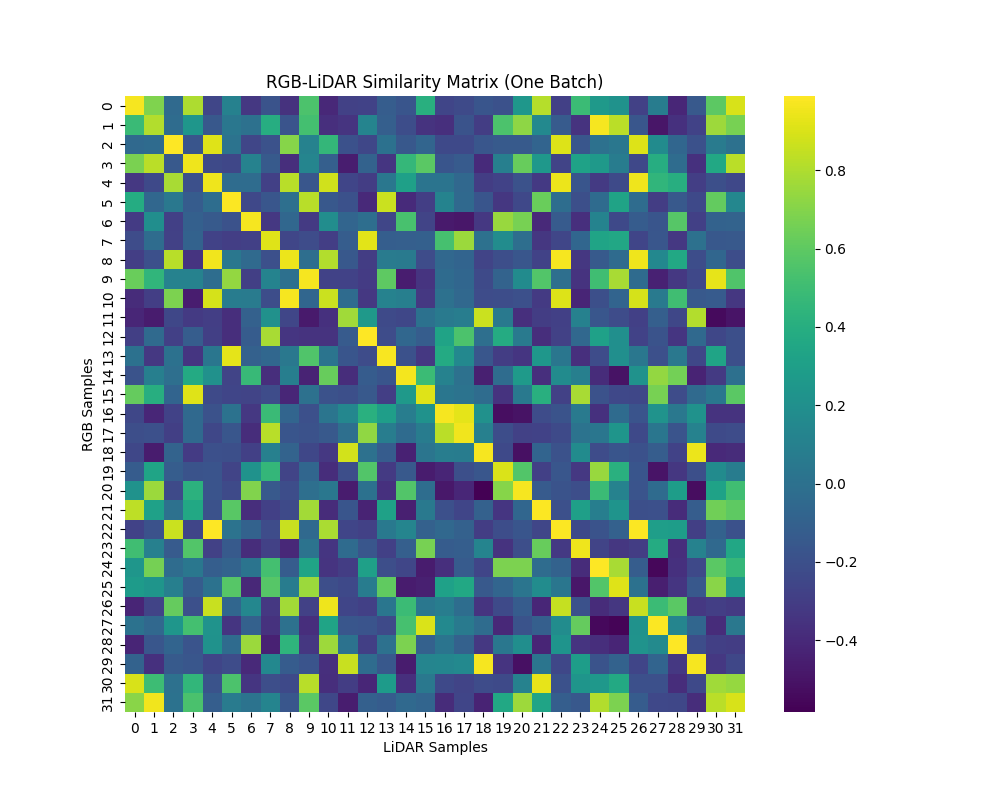

Note: Validation loss 2.56 < 3.2!

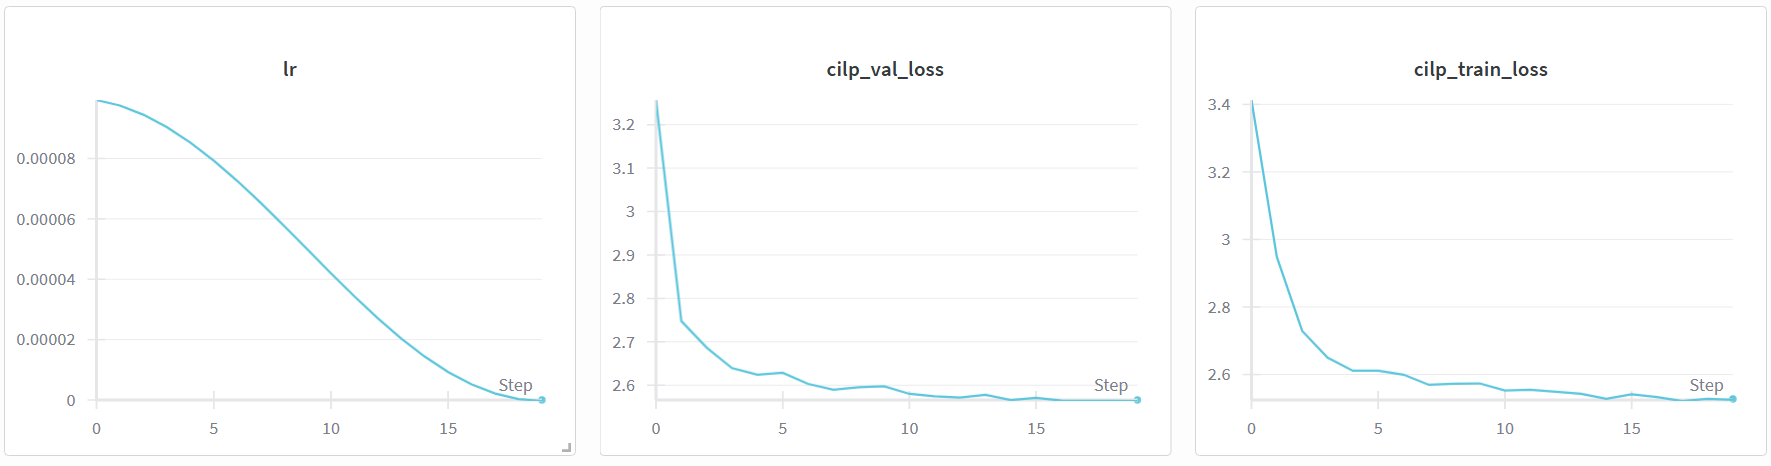

In [23]:
cilp_model.load_state_dict(torch.load("models/cilp_model_best.pth"))

<All keys matched successfully>

## 5. Task 5.2: Cross-Modal Projector

Train a projector to map RGB embeddings to LiDAR embeddings. We freeze the CILP encoders.

### Projector Architecture
The projector is a Multi-Layer Perceptron (MLP) designed to map the RGB embedding space to the LiDAR embedding space.
*   **Input**: RGB Embedding (Dimension: 128)
*   **Hidden Layers**: Two hidden layers with 256 units each, followed by ReLU activations.
*   **Output**: Projected Embedding (Dimension: 128, matching LiDAR space)
*   **Structure**: `Linear(128->256) -> ReLU -> Linear(256->256) -> ReLU -> Linear(256->128)`

### Training Details
*   **Objective**: Minimize the Mean Squared Error (MSE) between the projected RGB embedding and the corresponding ground-truth LiDAR embedding.
*   **Optimizer**: Adam
*   **Learning Rate**: 1e-3, with a StepLR scheduler (decay by 0.1 every 10 epochs).
*   **Constraints**: The pre-trained CILP encoders are **frozen** during this phase to preserve the learned alignment while learning the translation mapping.

In [24]:
class Projector(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(Projector, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

def train_projector(cilp_model, projector, train_loader, val_loader, config):
    wandb.init(entity="hpi-philipp-kolbe", project="cilp-extended-assessment", config=config, reinit=True, name="Projector_Training")
    
    cilp_model.eval() # Freeze CILP
    projector = projector.to(device)
    optimizer = optim.Adam(projector.parameters(), lr=config["lr"])
    criterion = nn.MSELoss()
    
    best_mse = float('inf')
    
    print("Starting Projector Training...")
    
    for epoch in range(config["epochs"]):
        projector.train()
        train_loss = 0.0
        
        for rgb, lidar, _ in train_loader:
            rgb, lidar = rgb.to(device), lidar.to(device)
            
            with torch.no_grad():
                rgb_emb, lidar_emb = cilp_model(rgb, lidar)
            
            optimizer.zero_grad()
            pred_lidar_emb = projector(rgb_emb)
            loss = criterion(pred_lidar_emb, lidar_emb)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
        
        # Validation
        projector.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for rgb, lidar, _ in val_loader:
                rgb, lidar = rgb.to(device), lidar.to(device)
                rgb_emb, lidar_emb = cilp_model(rgb, lidar)
                pred_lidar_emb = projector(rgb_emb)
                loss = criterion(pred_lidar_emb, lidar_emb)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        
        wandb.log({
            "epoch": epoch + 1,
            "proj_train_mse": avg_train_loss,
            "proj_val_mse": avg_val_loss
        })
        
        print(f"Epoch {epoch+1}/{config['epochs']} - Train MSE: {avg_train_loss:.4f} - Val MSE: {avg_val_loss:.4f}")
        
        if avg_val_loss < best_mse:
            best_mse = avg_val_loss
            torch.save(projector.state_dict(), "models/projector_best.pth")
            
    wandb.finish()
    return projector

# Config for Projector
proj_config = {
    "epochs": 20,
    "lr": 1e-3,
    "embedding_dim": 128
}

projector = Projector(proj_config["embedding_dim"], proj_config["embedding_dim"])
projector = train_projector(cilp_model, projector, train_loader, val_loader, proj_config)

Starting Projector Training...
Epoch 1/20 - Train MSE: 0.0069 - Val MSE: 0.0043
Epoch 2/20 - Train MSE: 0.0024 - Val MSE: 0.0014
Epoch 3/20 - Train MSE: 0.0008 - Val MSE: 0.0009
Epoch 4/20 - Train MSE: 0.0005 - Val MSE: 0.0008
Epoch 5/20 - Train MSE: 0.0004 - Val MSE: 0.0007
Epoch 6/20 - Train MSE: 0.0004 - Val MSE: 0.0007
Epoch 7/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 8/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 9/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 10/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 11/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 12/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 13/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 14/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 15/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 16/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 17/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 18/20 - Train MSE: 0.0003 - Val MSE: 0.0007
Epoch 19/20 - Train MSE: 0.0003 - Val MSE: 0.0007


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 20/20 - Train MSE: 0.0003 - Val MSE: 0.0007


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
proj_train_mse,█▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
proj_val_mse,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,20
proj_train_mse,0.00028
proj_val_mse,0.00071


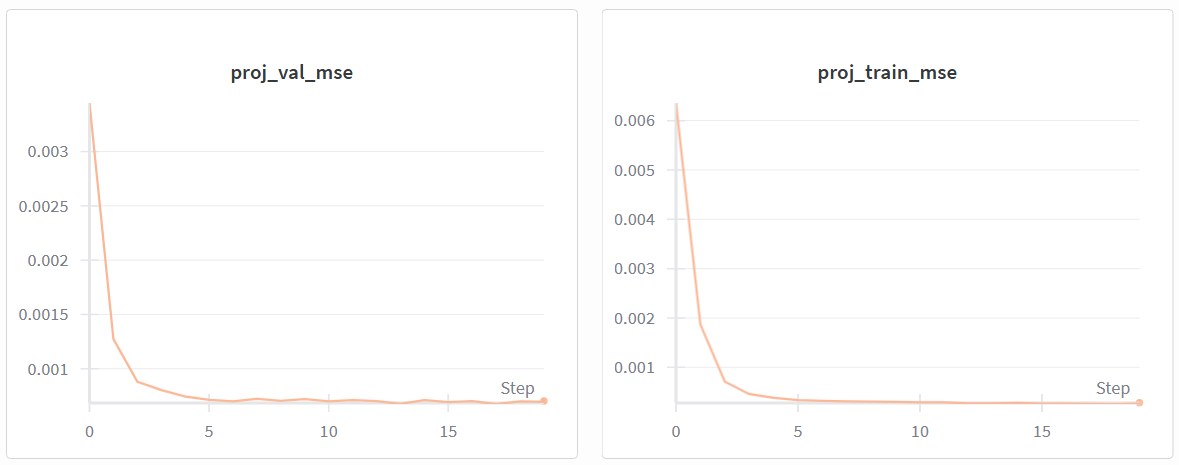

In [25]:
projector.load_state_dict(torch.load("models/projector_best.pth"))

<All keys matched successfully>

## 6. Task 5.3: Final Classifier

Train a classifier on LiDAR embeddings (Ground Truth geometry) and evaluate using projected RGB embeddings.

In [29]:
class Classifier(nn.Module):
    def __init__(self, input_dim):
        super(Classifier, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 1)
        )
        
    def forward(self, x):
        return self.net(x)

def train_classifier(cilp_model, classifier, train_loader, val_loader, config):
    wandb.init(entity="hpi-philipp-kolbe", project="cilp-extended-assessment", config=config, reinit=True, name="Classifier_Training")
    
    cilp_model.eval()
    classifier = classifier.to(device)
    
    # Added weight decay for regularization
    optimizer = optim.Adam(classifier.parameters(), lr=config["lr"], weight_decay=config.get("weight_decay", 1e-4))
    
    # Added LR Scheduler to decay LR when validation accuracy plateaus
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=config.get("factor", 0.5), patience=config.get("patience", 5))
    
    criterion = nn.BCEWithLogitsLoss()
    
    best_acc = 0.0
    
    print("Starting Classifier Training (on LiDAR embeddings)...")
    
    for epoch in range(config["epochs"]):
        classifier.train()
        train_loss = 0.0
        train_preds = []
        train_targets = []
        
        for _, lidar, labels in train_loader:
            lidar, labels = lidar.to(device), labels.to(device)
            
            with torch.no_grad():
                # Use LiDAR encoder directly
                lidar_emb = cilp_model.lidar_encoder(lidar)
                lidar_emb = F.normalize(lidar_emb, p=2, dim=1)
            
            optimizer.zero_grad()
            outputs = classifier(lidar_emb).squeeze()
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            train_preds.extend(torch.sigmoid(outputs).detach().cpu().numpy() > 0.5)
            train_targets.extend(labels.cpu().numpy())
            
        avg_train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_targets, train_preds)
        
        # Validation
        classifier.eval()
        val_loss = 0.0
        val_preds = []
        val_targets = []
        
        with torch.no_grad():
            for _, lidar, labels in val_loader:
                lidar, labels = lidar.to(device), labels.to(device)
                lidar_emb = cilp_model.lidar_encoder(lidar)
                lidar_emb = F.normalize(lidar_emb, p=2, dim=1)
                
                outputs = classifier(lidar_emb).squeeze()
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                val_preds.extend(torch.sigmoid(outputs).cpu().numpy() > 0.5)
                val_targets.extend(labels.cpu().numpy())
                
        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_targets, val_preds)
        
        # Step scheduler based on validation accuracy
        scheduler.step(val_acc)
        
        wandb.log({
            "epoch": epoch + 1,
            "cls_train_loss": avg_train_loss,
            "cls_train_acc": train_acc,
            "cls_val_loss": avg_val_loss,
            "cls_val_acc": val_acc,
            "lr": optimizer.param_groups[0]['lr']
        })
        
        print(f"Epoch {epoch+1}/{config['epochs']} - Train Loss: {avg_train_loss:.4f} - Val Acc: {val_acc:.4f} - LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(classifier.state_dict(), "models/classifier_best.pth")
            
    wandb.finish()
    return classifier

# Config for Classifier
cls_config = {
    "epochs": 50,
    "lr": 1e-3,        # Reduced from 1e-2 to prevent overshooting
    "weight_decay": 1e-4, # Added for regularization
    "embedding_dim": 128,
    "factor": 0.5,     # LR reduction factor
    "patience": 5      # Patience for LR scheduler
}

classifier = Classifier(cls_config["embedding_dim"])
classifier = train_classifier(cilp_model, classifier, train_loader, val_loader, cls_config)

Starting Classifier Training (on LiDAR embeddings)...
Epoch 1/50 - Train Loss: 0.6951 - Val Acc: 0.4688 - LR: 0.001000
Epoch 2/50 - Train Loss: 0.6936 - Val Acc: 0.6042 - LR: 0.001000
Epoch 3/50 - Train Loss: 0.6926 - Val Acc: 0.6042 - LR: 0.001000
Epoch 4/50 - Train Loss: 0.6908 - Val Acc: 0.6042 - LR: 0.001000
Epoch 5/50 - Train Loss: 0.6884 - Val Acc: 0.6042 - LR: 0.001000
Epoch 6/50 - Train Loss: 0.6880 - Val Acc: 0.5833 - LR: 0.001000
Epoch 7/50 - Train Loss: 0.6882 - Val Acc: 0.6042 - LR: 0.001000
Epoch 8/50 - Train Loss: 0.6850 - Val Acc: 0.6042 - LR: 0.000500
Epoch 9/50 - Train Loss: 0.6815 - Val Acc: 0.6458 - LR: 0.000500
Epoch 10/50 - Train Loss: 0.6781 - Val Acc: 0.5938 - LR: 0.000500
Epoch 11/50 - Train Loss: 0.6782 - Val Acc: 0.5625 - LR: 0.000500
Epoch 12/50 - Train Loss: 0.6750 - Val Acc: 0.5938 - LR: 0.000500
Epoch 13/50 - Train Loss: 0.6710 - Val Acc: 0.5729 - LR: 0.000500
Epoch 14/50 - Train Loss: 0.6678 - Val Acc: 0.6250 - LR: 0.000500
Epoch 15/50 - Train Loss: 0.662

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


Epoch 50/50 - Train Loss: 0.6285 - Val Acc: 0.5938 - LR: 0.000008


cls_train_acc,▁▂▃▃▄▄▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇██▇▇▇▇█▇█▇█▇▇▇
cls_train_loss,████▇▇▇▆▆▆▅▅▄▄▄▃▃▃▃▂▂▂▂▁▂▂▁▁▂▁▂▁▁▁▁▁▁▂▂▁
cls_val_acc,▁▆▆▆▆▆▆█▆▅▅▇▅▆▄▆▄▄▅▆▆▆▆▆▆▆▅▆▆▆▆▆▆▆▆▆▆▆▆▆
cls_val_loss,█▇▇▇▇▅▅▅▆▆▅▃▅▄▄▃▃▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
lr,█████▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
cls_train_acc,0.64167
cls_train_loss,0.62853
cls_val_acc,0.59375
cls_val_loss,0.66178
epoch,50


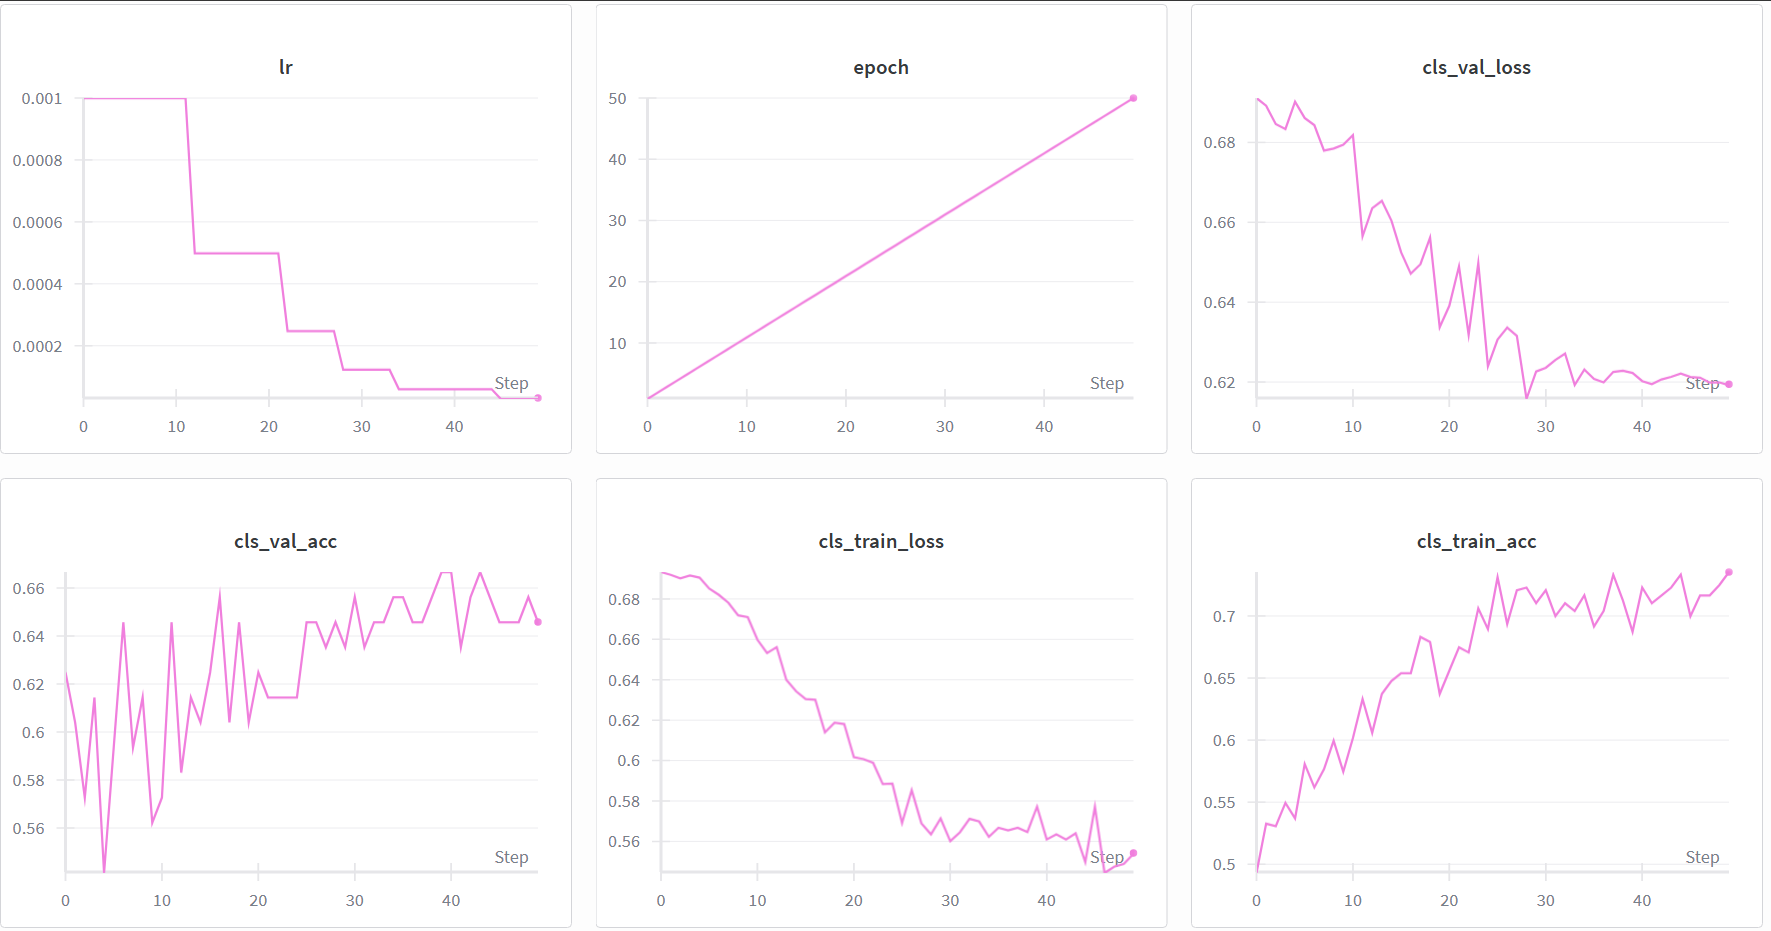

In [30]:
classifier.load_state_dict(torch.load("models/classifier_best.pth"))

<All keys matched successfully>

## 7. Final Evaluation (RGB -> Projector -> Classifier)

Evaluate the full pipeline on the Test Set.

Evaluating RGB -> Projector -> Classifier pipeline...
Final Test Accuracy: 0.5729
Final Test F1 Score: 0.3881


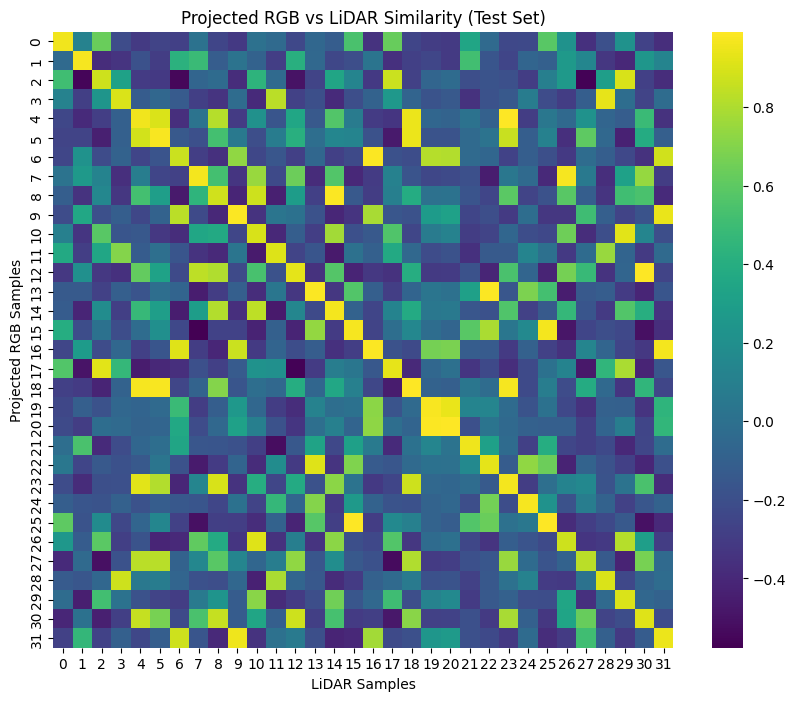

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


test_accuracy,▁
test_f1,▁
test_accuracy,0.57292
test_f1,0.38806


(0.5729166666666666, 0.3880597014925373)

In [31]:
def log_sample_predictions(rgb_imgs, targets, preds, num_samples=5):
    """Log sample predictions to W&B."""
    table = wandb.Table(columns=["Image", "Ground Truth", "Prediction"])
    
    for i in range(min(num_samples, len(rgb_imgs))):
        img = rgb_imgs[i].cpu().permute(1, 2, 0).numpy()
        # Denormalize if needed, here assuming [0,1]
        
        gt_label = "Sphere" if targets[i] == 1 else "Cube"
        pred_label = "Sphere" if preds[i] else "Cube"
        
        table.add_data(wandb.Image(img), gt_label, pred_label)
        
    wandb.log({"sample_predictions": table})

def evaluate_pipeline(cilp_model, projector, classifier, loader):
    wandb.init(entity="hpi-philipp-kolbe", project="cilp-extended-assessment", name="Final_Evaluation", reinit=True)
    
    cilp_model.eval()
    projector.eval()
    classifier.eval()
    
    all_preds = []
    all_targets = []
    all_rgb = []
    
    print("Evaluating RGB -> Projector -> Classifier pipeline...")
    
    with torch.no_grad():
        for rgb, _, labels in loader:
            rgb, labels = rgb.to(device), labels.to(device)
            
            # 1. RGB Encoder
            rgb_emb = cilp_model.rgb_encoder(rgb)
            rgb_emb = F.normalize(rgb_emb, p=2, dim=1)
            
            # 2. Projector (RGB -> LiDAR space)
            proj_emb = projector(rgb_emb)
            
            # 3. Classifier (Trained on LiDAR space)
            outputs = classifier(proj_emb).squeeze()
            
            preds = torch.sigmoid(outputs).cpu().numpy() > 0.5
            all_preds.extend(preds)
            all_targets.extend(labels.cpu().numpy())
            
            # Store some images for logging
            if len(all_rgb) < 10:
                all_rgb.extend(rgb)
            
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    
    print(f"Final Test Accuracy: {acc:.4f}")
    print(f"Final Test F1 Score: {f1:.4f}")
    
    wandb.log({
        "test_accuracy": acc,
        "test_f1": f1
    })
    
    # Log samples
    log_sample_predictions(all_rgb, all_targets, all_preds, num_samples=5)

    # Log Similarity Matrix (Projected RGB vs LiDAR)
    # This visualizes how well the projector maps RGB to the LiDAR embedding space
    rgb, lidar, _ = next(iter(loader))
    rgb, lidar = rgb.to(device), lidar.to(device)
    
    with torch.no_grad():
        # Get Projected RGB Embeddings
        rgb_emb = cilp_model.rgb_encoder(rgb)
        rgb_emb = F.normalize(rgb_emb, p=2, dim=1)
        proj_emb = projector(rgb_emb)
        proj_emb = F.normalize(proj_emb, p=2, dim=1) # Normalize for cosine similarity
        
        # Get Ground Truth LiDAR Embeddings
        lidar_emb = cilp_model.lidar_encoder(lidar)
        lidar_emb = F.normalize(lidar_emb, p=2, dim=1)
        
        # Calculate Similarity
        similarity = torch.matmul(proj_emb, lidar_emb.T).cpu().numpy()
        
    plt.figure(figsize=(10, 8))
    sns.heatmap(similarity, cmap="viridis")
    plt.title("Projected RGB vs LiDAR Similarity (Test Set)")
    plt.xlabel("LiDAR Samples")
    plt.ylabel("Projected RGB Samples")
    wandb.log({"projected_similarity_matrix": wandb.Image(plt)})
    plt.show()
    
    wandb.finish()
    return acc, f1

# Run Evaluation on Test Set
evaluate_pipeline(cilp_model, projector, classifier, test_loader)

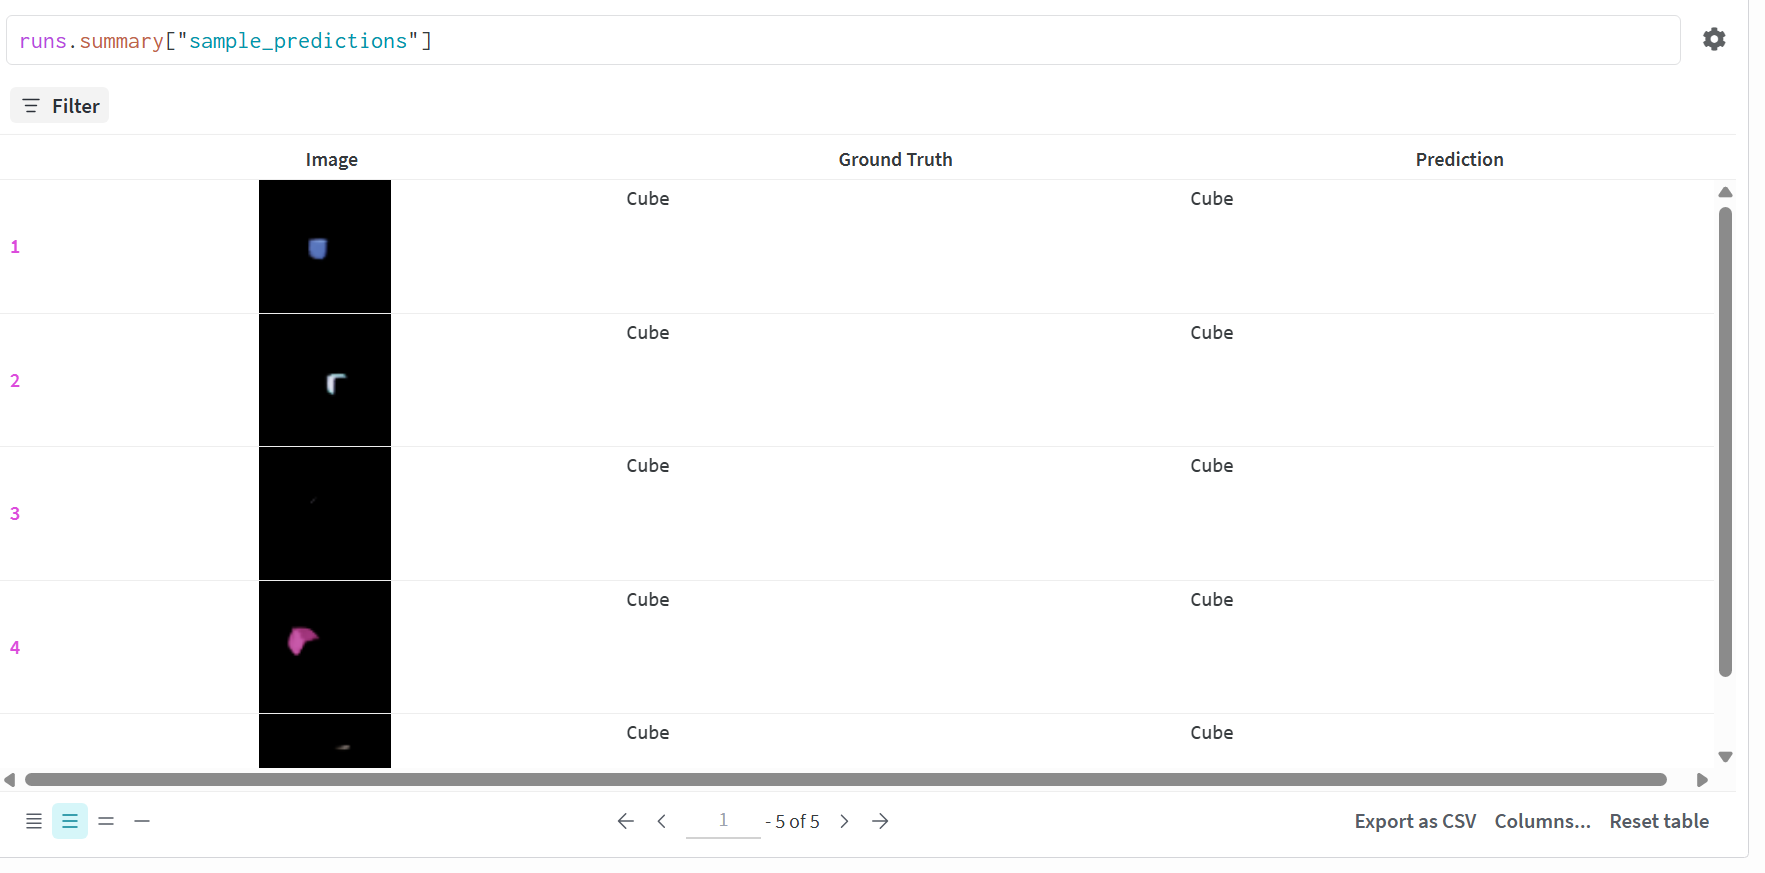